# 🏦 Loan Default Prediction — Complete Analysis

**Dataset**: Loan Default Dataset (148,670 rows × 34 columns)  
**Task**: Binary classification — predict whether a borrower will default on a loan (`Status` = 1) or not (`Status` = 0)  
**Key Challenge**: Moderate class imbalance (~75% Rejected , ~25% Accepted)

---
## 📋 Table of Contents
1. [Imports & Setup](#1)
2. [Data Loading & Overview](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Cleaning & Preprocessing](#4)
5. [Feature Engineering](#5)
6. [Handling Imbalanced Data](#6)
7. [Model Selection & Evaluation](#7)
8. [Results & Insights](#8)
9. [Best Model Deep Dive](#9)
10. [Hyperparameter Tuning](#10)
11. [Stratified Cross-Validation](#11)
12. [Feature Importance](#12)
13. [Threshold Optimization and Confusion Matrix](#13)
14.  [Production Pipeline](#14)

---
##  1. Imports & Setup <a id='1'></a>

In [103]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      RandomizedSearchCV)
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,

                             f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']
RANDOM_STATE = 42

---
##  2. Data Loading & Overview <a id='2'></a>

In [104]:
df = pd.read_csv(r'D:\Project\Loan_Default.csv')

In [105]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [106]:
df.shape

(148670, 34)

In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

In [108]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [109]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(f'Columns with missing values: {len(missing_df)}')
missing_df

Columns with missing values: 14


,Missing Count,Missing %
Upfront_charges,39642,26.66
Interest_rate_spread,36639,24.64
rate_of_interest,36439,24.51
dtir1,24121,16.22
property_value,15098,10.16
LTV,15098,10.16
income,9150,6.15
loan_limit,3344,2.25
approv_in_adv,908,0.61
submission_of_application,200,0.13


In [110]:
df.duplicated().sum()

np.int64(0)

---
##  3. Exploratory Data Analysis (EDA) <a id='3'></a>

### 3.1 Target Variable — Loan Default Distribution

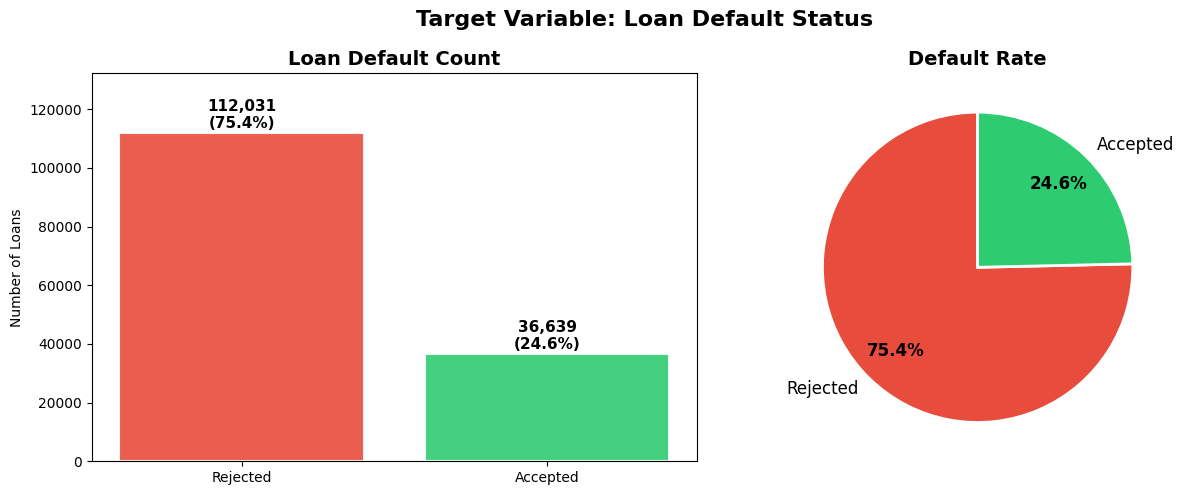


Class Distribution:
  Rejected: 112,031 (75.4%)
  Accepted:    36,639 (24.6%)

Imbalance Ratio: 3.06:1 (majority:minority)


In [111]:
status_counts = df['Status'].value_counts().sort_index()
labels = ['Rejected', 'Accepted']
colors = ['#e74c3c','#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(labels, status_counts.values, color=colors, edgecolor='white', linewidth=1.5, alpha=0.9)
axes[0].set_title('Loan Default Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Loans')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{val:,}\n({val / len(df) * 100:.1f}%)',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )
axes[0].set_ylim(0, max(status_counts.values) * 1.18)

wedges, texts, autotexts = axes[1].pie(
    status_counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Default Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Loan Default Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = status_counts[0] / status_counts[1]
print(f'\nClass Distribution:')
print(f'  Rejected: {status_counts[0]:,} ({status_counts[0]/len(df)*100:.1f}%)')
print(f'  Accepted:    {status_counts[1]:,} ({status_counts[1]/len(df)*100:.1f}%)')
print(f'\nImbalance Ratio: {imbalance_ratio:.2f}:1 (majority:minority)')

### Class Imbalance

> The dataset is **moderately imbalanced** — approximately **75.4% Rejected** vs **24.6% Accepted** (~3:1 ratio).
>
> **A naive classifier always predicting "Rejected" would score ~75.4% accuracy** — which is misleading!  
> We must:
> - Use `class_weight=class_weights` for models that support it
> - Evaluate with **ROC-AUC**, **F1-Macro**, and **Recall** in addition to accuracy
>
> **Note:** SMOTE (synthetic oversampling) was tested during development but was dropped from the final pipeline — it introduced synthetic, unrealistic borderline samples that hurt generalisation on the real test set and made results harder to trust. `class_weight=class_weights` gave more stable, honest results without inventing data, so it is the only imbalance-handling technique used below.


### 3.2 Missing Values Analysis

c:\Users\ahmed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


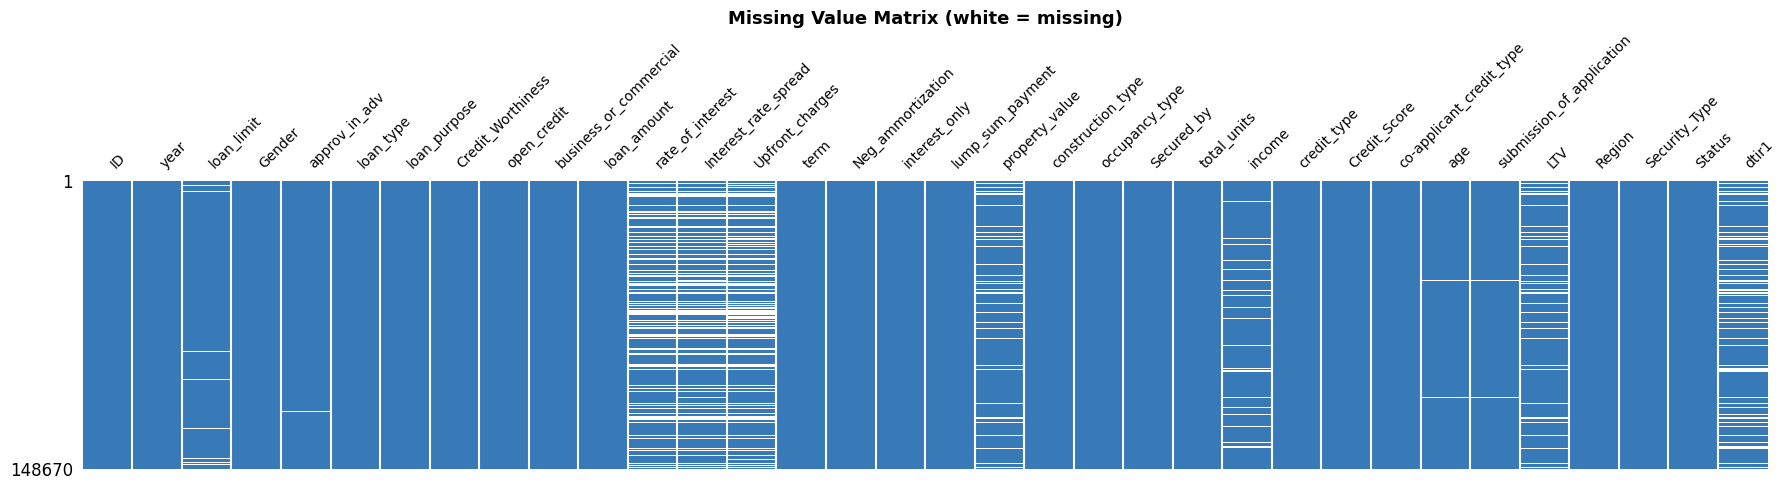

In [112]:
fig, ax = plt.subplots(figsize=(18, 5))
msno.matrix(df, ax=ax, color=(0.22, 0.48, 0.72), fontsize=10)
ax.set_title('Missing Value Matrix (white = missing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

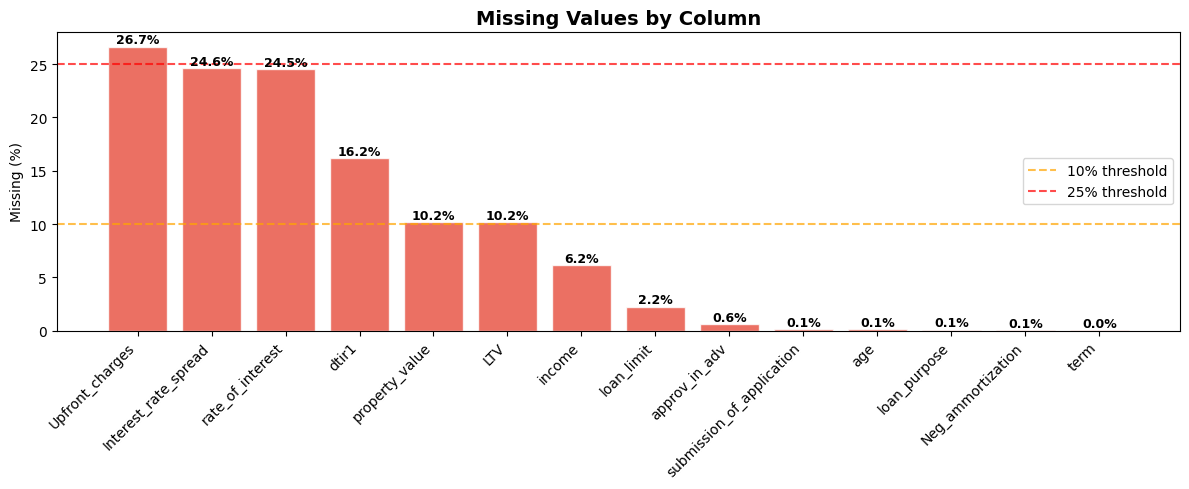

In [113]:
missing_plot = missing_df.copy()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(missing_plot.index, missing_plot['Missing %'],
              color='#e74c3c', alpha=0.8, edgecolor='white', linewidth=1)
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
ax.axhline(y=10, color='orange', linestyle='--', alpha=0.7, label='10% threshold')
ax.axhline(y=25, color='red', linestyle='--', alpha=0.7, label='25% threshold')
ax.legend()
for bar, val in zip(bars, missing_plot['Missing %']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### Missing Values

| Column | Missing % | Likely Reason |
|--------|-----------|---------------|
| `Upfront_charges` | ~26.7% | Not applicable for all loan types |
| `Interest_rate_spread` | ~24.6% | Tied to `rate_of_interest` missingness |
| `rate_of_interest` | ~24.5% | Fixed-rate loans may not report spread |
| `dtir1` (Debt-to-Income) | ~16.2% | Not always collected |
| `property_value` & `LTV` | ~10.2% | Both missing together (LTV = loan/property) |

**Strategy**: Median imputation for numeric columns (robust to outliers), mode imputation for categorical columns.

### 3.3 Numerical Feature Distributions

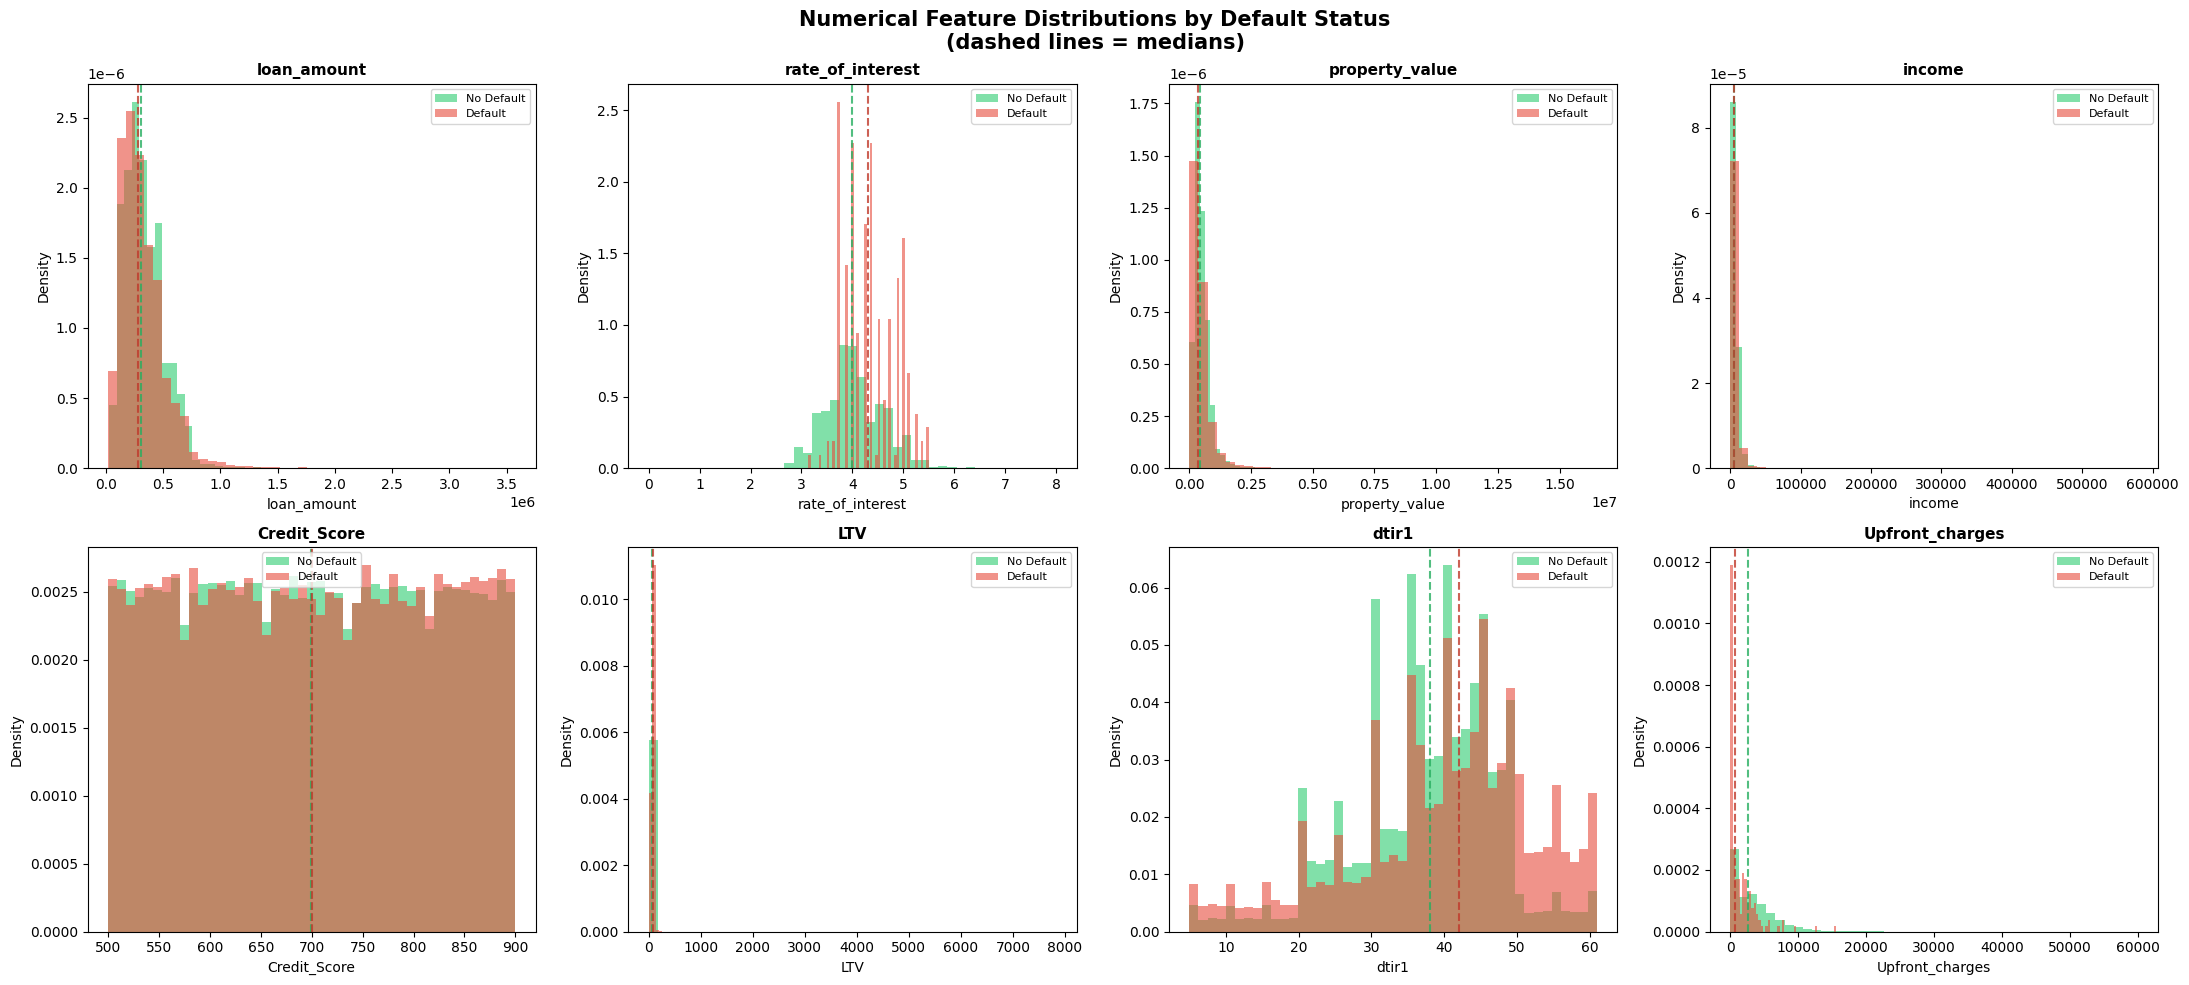

In [114]:
num_plot_cols = [
    'loan_amount', 'rate_of_interest', 'property_value',
    'income', 'Credit_Score', 'LTV', 'dtir1', 'Upfront_charges'
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, col in enumerate(num_plot_cols):
    data_0 = df[df['Status'] == 0][col].dropna()
    data_1 = df[df['Status'] == 1][col].dropna()

    axes[idx].hist(data_0, bins=45, alpha=0.6, label='No Default', color='#2ecc71', density=True)
    axes[idx].hist(data_1, bins=45, alpha=0.6, label='Default', color='#e74c3c', density=True)
    axes[idx].axvline(data_0.median(), color='#27ae60', linestyle='--', linewidth=1.5, alpha=0.8)
    axes[idx].axvline(data_1.median(), color='#c0392b', linestyle='--', linewidth=1.5, alpha=0.8)

    axes[idx].set_title(col, fontweight='bold', fontsize=11)
    axes[idx].legend(fontsize=8)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')

plt.suptitle('Numerical Feature Distributions by Default Status\n(dashed lines = medians)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

###  Numerical Features

| Feature | Observation |
|---------|-------------|
| **Credit Score** | Defaulters concentrated in 500–650 range; non-defaulters skewed toward higher scores |
| **LTV (Loan-to-Value)** | Defaulters have higher LTV — borrowing more relative to property value |
| **Income** | Lower-income borrowers show higher default rates |
| **Rate of Interest** | Defaulters tend to have slightly higher interest rates (risk-based pricing) |
| **Debt-to-Income (dtir1)** | Higher DTI ratios correlate with defaults |
| **Loan Amount** | Similar distributions — loan amount alone is weak signal |
| **Upfront Charges** | Wide spread for defaulters; high charges may indicate riskier products |

### 3.4 Correlation Heatmap

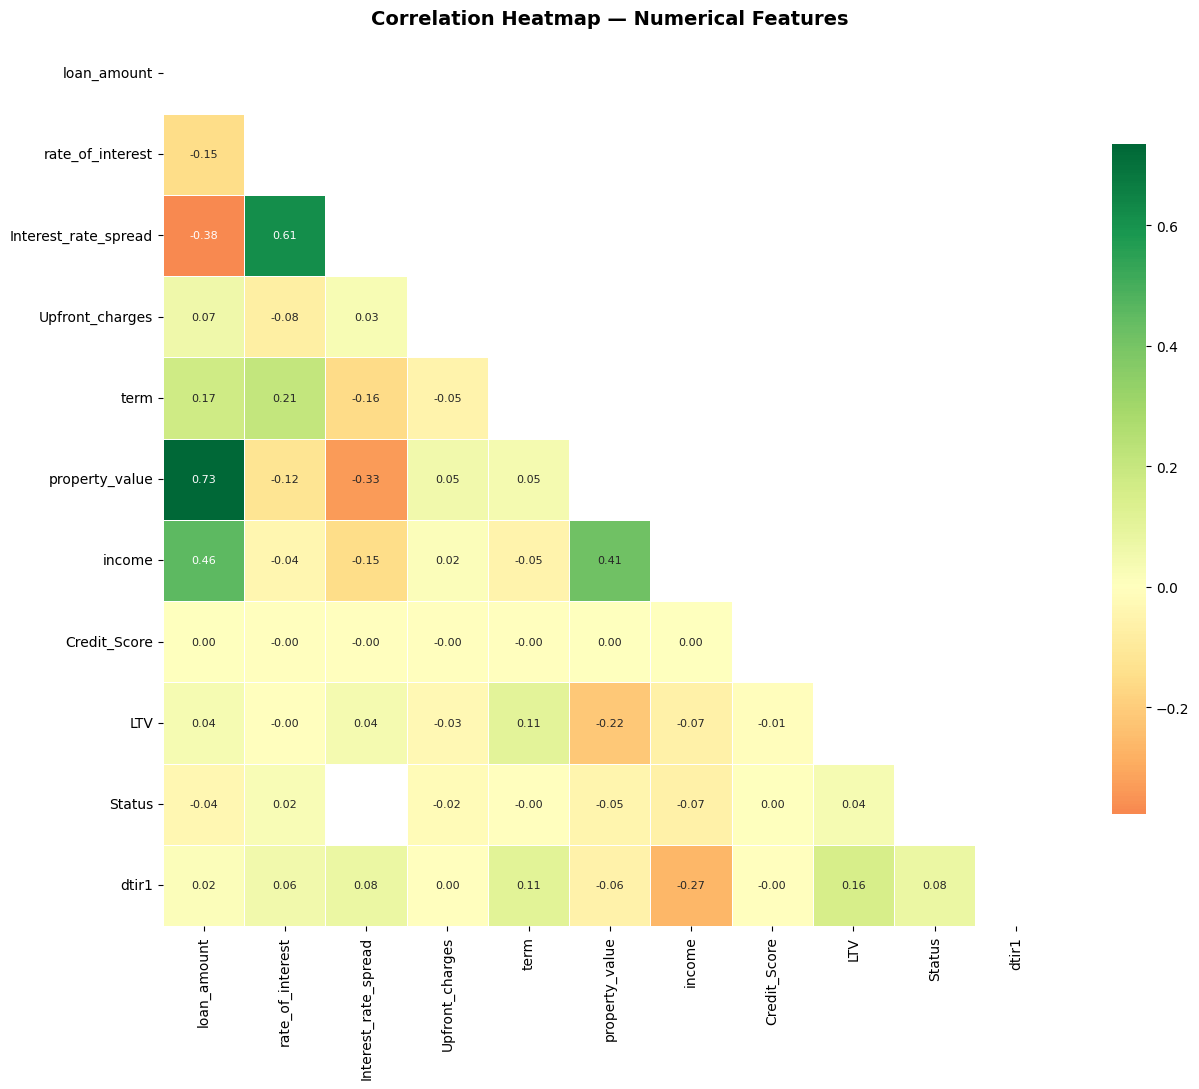

In [115]:
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['ID', 'year'], errors='ignore')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.4, cbar_kws={'shrink': 0.75},
    annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlations

- **`LTV` ↔ `property_value`**: Moderately negative — higher-value properties → lower LTV
- **`loan_amount` ↔ `property_value`**: Positive — larger loans for higher-value properties
- **`rate_of_interest` ↔ `Interest_rate_spread`**: High correlation — consider dropping one for linear models
- **`Status`**: Weak individual correlations with most features → complex non-linear interactions likely → **tree-based models are expected to outperform linear models**

### 3.5 Categorical Feature Analysis

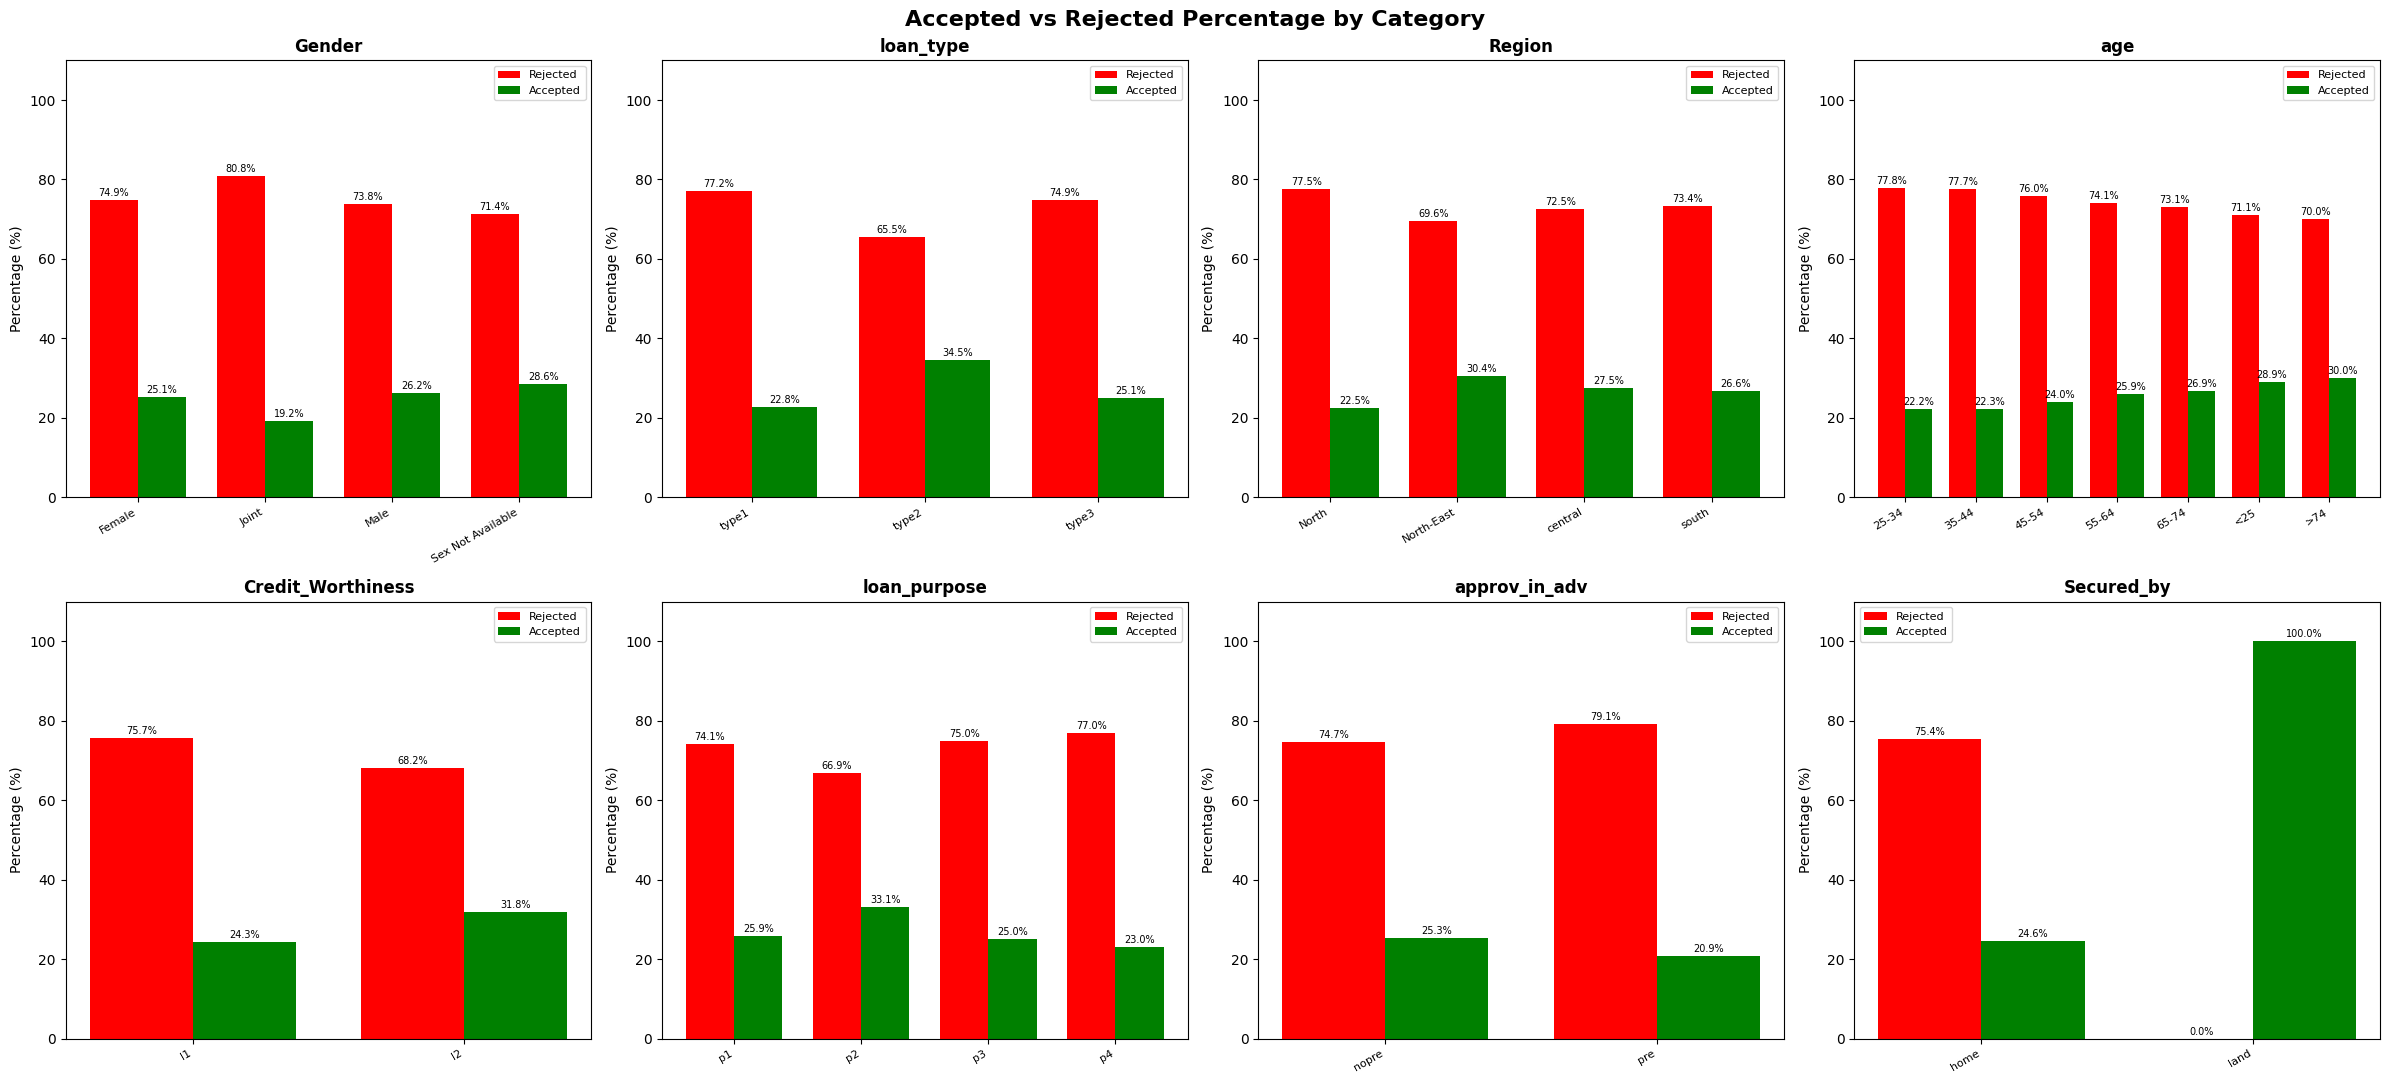

In [116]:
cat_plot_cols = [
    'Gender', 'loan_type', 'Region', 'age',
    'Credit_Worthiness', 'loan_purpose',
    'approv_in_adv', 'Secured_by'
]

fig, axes = plt.subplots(2, 4, figsize=(24, 11))
axes = axes.flatten()

for idx, col in enumerate(cat_plot_cols):

    perc = (
        pd.crosstab(df[col], df['Status'], normalize='index') * 100
    )

    perc = perc.reindex(columns=[0, 1], fill_value=0)

    x = np.arange(len(perc.index))
    width = 0.38

    axes[idx].bar(
        x - width/2,
        perc[0],
        width,
        label='Rejected',
        color='Red'
    )

    axes[idx].bar(
        x + width/2,
        perc[1],
        width,
        label='Accepted',
        color='Green'
    )

    for i, (rej, acc) in enumerate(zip(perc[0], perc[1])):
        axes[idx].text(i-width/2, rej+1, f'{rej:.1f}%',
                       ha='center', fontsize=7)
        axes[idx].text(i+width/2, acc+1, f'{acc:.1f}%',
                       ha='center', fontsize=7)

    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(
        perc.index.astype(str),
        rotation=30,
        ha='right',
        fontsize=8
    )

    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].set_ylim(0, 110)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].legend(fontsize=8)

plt.suptitle(
    'Accepted vs Rejected Percentage by Category',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

###Categorical Features
| Feature               | Insight                                                                                                            |
| --------------------- | ------------------------------------------------------------------------------------------------------------------ |
| **Gender**            | **Joint** applicants have the highest rejection rate, while **Sex Not Available** has the highest acceptance rate. |
| **Loan Type**         | **Type2** loans have the highest acceptance rate; **Type1** and **Type3** are rejected more often.                 |
| **Region**            | **North-East** has the highest acceptance rate, while **North** has the highest rejection rate.                    |
| **Age**               | Older applicants (≈75 years) show slightly higher acceptance; age has only a modest effect.                        |
| **Credit Worthiness** | **Credit_Worthiness = 1** is associated with a higher acceptance rate than **0**.                                  |
| **Loan Purpose**      | **P2** has the highest acceptance rate, while **P4** has the lowest.                                               |
| **Pre-approval**      | **nopre** applicants have a slightly higher acceptance rate than **pre** applicants.                               |
| **Secured By**        | Category **1** shows 100% acceptance, suggesting a very small or highly imbalanced group; interpret with caution.  |

### 3.6 Boxplots: Key Financial Metrics

C:\Users\ahmed\AppData\Local\Temp\ipykernel_5080\13353213.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\ahmed\AppData\Local\Temp\ipykernel_5080\13353213.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\ahmed\AppData\Local\Temp\ipykernel_5080\13353213.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\ahmed\AppData\Local\Temp\ipykernel_5080\13353213.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.b

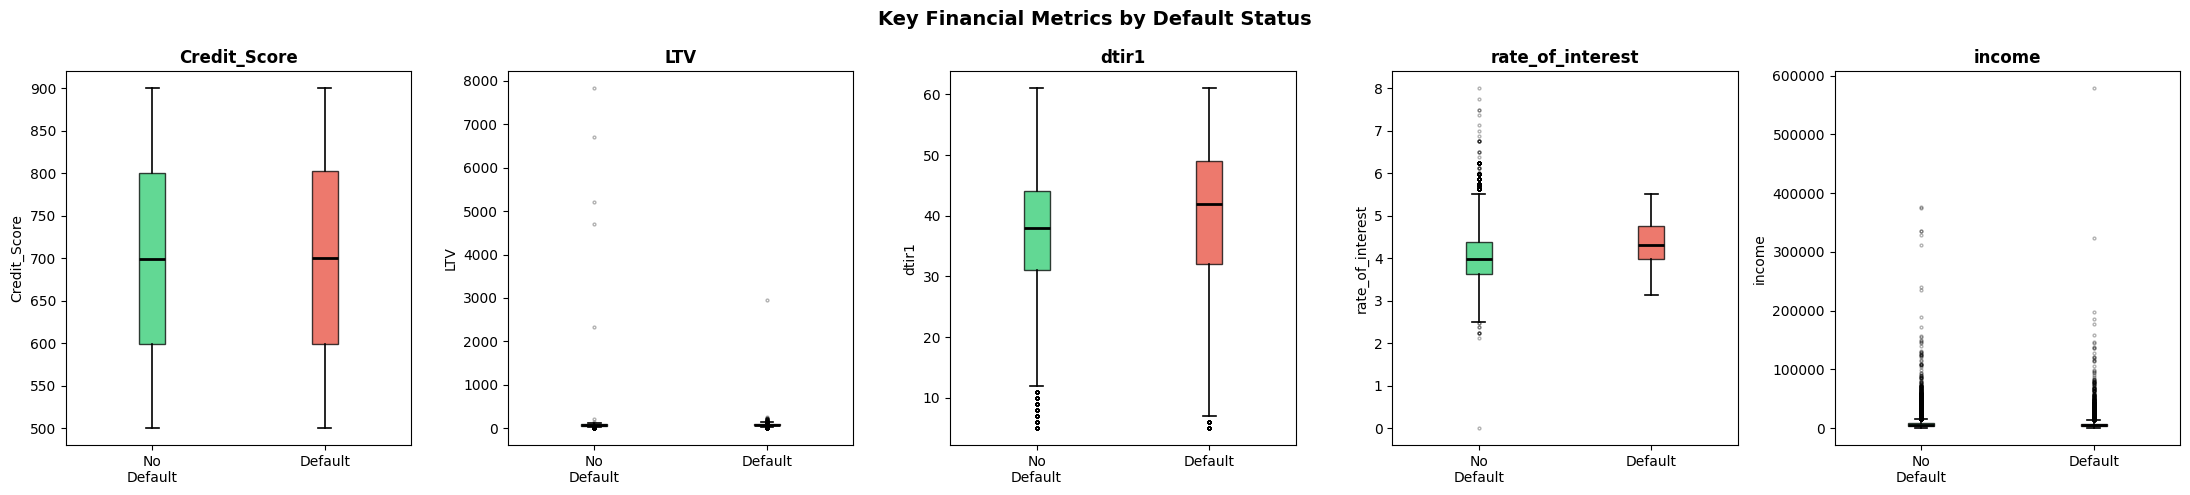

In [117]:
box_cols = ['Credit_Score', 'LTV', 'dtir1', 'rate_of_interest', 'income']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, col in zip(axes, box_cols):
    data_0 = df[df['Status'] == 0][col].dropna()
    data_1 = df[df['Status'] == 1][col].dropna()

    bp = ax.boxplot(
        [data_0, data_1],
        labels=['No\nDefault', 'Default'],
        patch_artist=True,
        boxprops=dict(alpha=0.75),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', alpha=0.3, markersize=2)
    )
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')

    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Key Financial Metrics by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  EDA Summary

| Finding | Implication |
|---------|-------------|
| 75.4% Rejected / 24.6% Accepted | Must handle class imbalance (`class_weight=class_weights`; SMOTE tested but dropped — see note) |
| Credit Score separates classes well | Strong predictive feature |
| LTV strongly correlated with default | Important engineered ratio |
| Several columns missing 10–27% | Median/mode imputation needed |
| Weak linear correlations with target | Ensemble/tree models expected to outperform linear |
| Regional and demographic differences | Categorical features add value |

---

##  4. Data Cleaning & Preprocessing <a id='4'></a>

In [118]:
df.drop(columns='ID' , inplace = True )

In [119]:
df['year'].unique()

array([2019])

In [120]:
df.drop(columns='year' , inplace = True)

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
cat = df.select_dtypes(include=['object','category']).columns

C:\Users\ahmed\AppData\Local\Temp\ipykernel_5080\245132307.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include=['object','category']).columns


In [123]:
len(cat)

21

In [124]:
cat

Index(['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'Credit_Worthiness', 'open_credit', 'business_or_commercial',
       'Neg_ammortization', 'interest_only', 'lump_sum_payment',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'credit_type', 'co-applicant_credit_type', 'age',
       'submission_of_application', 'Region', 'Security_Type'],
      dtype='str')

In [125]:
for col in cat :
    print(col)
    print(df[col].unique())

loan_limit
<StringArray>
['cf', nan, 'ncf']
Length: 3, dtype: str
Gender
<StringArray>
['Sex Not Available', 'Male', 'Joint', 'Female']
Length: 4, dtype: str
approv_in_adv
<StringArray>
['nopre', 'pre', nan]
Length: 3, dtype: str
loan_type
<StringArray>
['type1', 'type2', 'type3']
Length: 3, dtype: str
loan_purpose
<StringArray>
['p1', 'p4', 'p3', 'p2', nan]
Length: 5, dtype: str
Credit_Worthiness
<StringArray>
['l1', 'l2']
Length: 2, dtype: str
open_credit
<StringArray>
['nopc', 'opc']
Length: 2, dtype: str
business_or_commercial
<StringArray>
['nob/c', 'b/c']
Length: 2, dtype: str
Neg_ammortization
<StringArray>
['not_neg', 'neg_amm', nan]
Length: 3, dtype: str
interest_only
<StringArray>
['not_int', 'int_only']
Length: 2, dtype: str
lump_sum_payment
<StringArray>
['not_lpsm', 'lpsm']
Length: 2, dtype: str
construction_type
<StringArray>
['sb', 'mh']
Length: 2, dtype: str
occupancy_type
<StringArray>
['pr', 'sr', 'ir']
Length: 3, dtype: str
Secured_by
<StringArray>
['home', 'land']
L

In [126]:
df.isna().sum()

loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_application      200
LTV                          15098
Region              

In [127]:
df['age'].value_counts()

age
45-54    34720
35-44    32818
55-64    32534
65-74    20744
25-34    19142
>74       7175
<25       1337
Name: count, dtype: int64

In [128]:
def edit_age(age):
    if pd.isna(age):
        return np.nan

    if '-' in age:
        lis = age.split('-')
        return (int(lis[0]) + int(lis[1])) / 2

    elif '<' in age:
        return 20
    elif '>' in age:
        return 75
    return age

df['age'] = df['age'].apply(edit_age)

In [129]:
num = df.select_dtypes(include=['int64' , 'float64']).columns

In [130]:
num

Index(['loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'age', 'LTV', 'Status', 'dtir1'],
      dtype='str')

In [131]:
binary_cat = []
for col in cat  :
    if(len(df[col].unique())==2) :
        binary_cat.append(col)
binary_cat

['Credit_Worthiness',
 'open_credit',
 'business_or_commercial',
 'interest_only',
 'lump_sum_payment',
 'construction_type',
 'Secured_by',
 'co-applicant_credit_type',
 'Security_Type']

In [132]:
nominal_cat = []
for col in cat :
    if col not in binary_cat :
        nominal_cat.append(col)
nominal_cat

['loan_limit',
 'Gender',
 'approv_in_adv',
 'loan_type',
 'loan_purpose',
 'Neg_ammortization',
 'occupancy_type',
 'total_units',
 'credit_type',
 'age',
 'submission_of_application',
 'Region']

In [133]:
df.drop(columns = ['Upfront_charges' , 'Interest_rate_spread'] , inplace = True)

> Feature Selection: Upfront_charges and Interest_rate_spread were removed because they contained a large number of missing values. Keeping them required extensive imputation and resulted in poorer generalization (higher overfitting). Excluding these features produced a more robust and stable model.



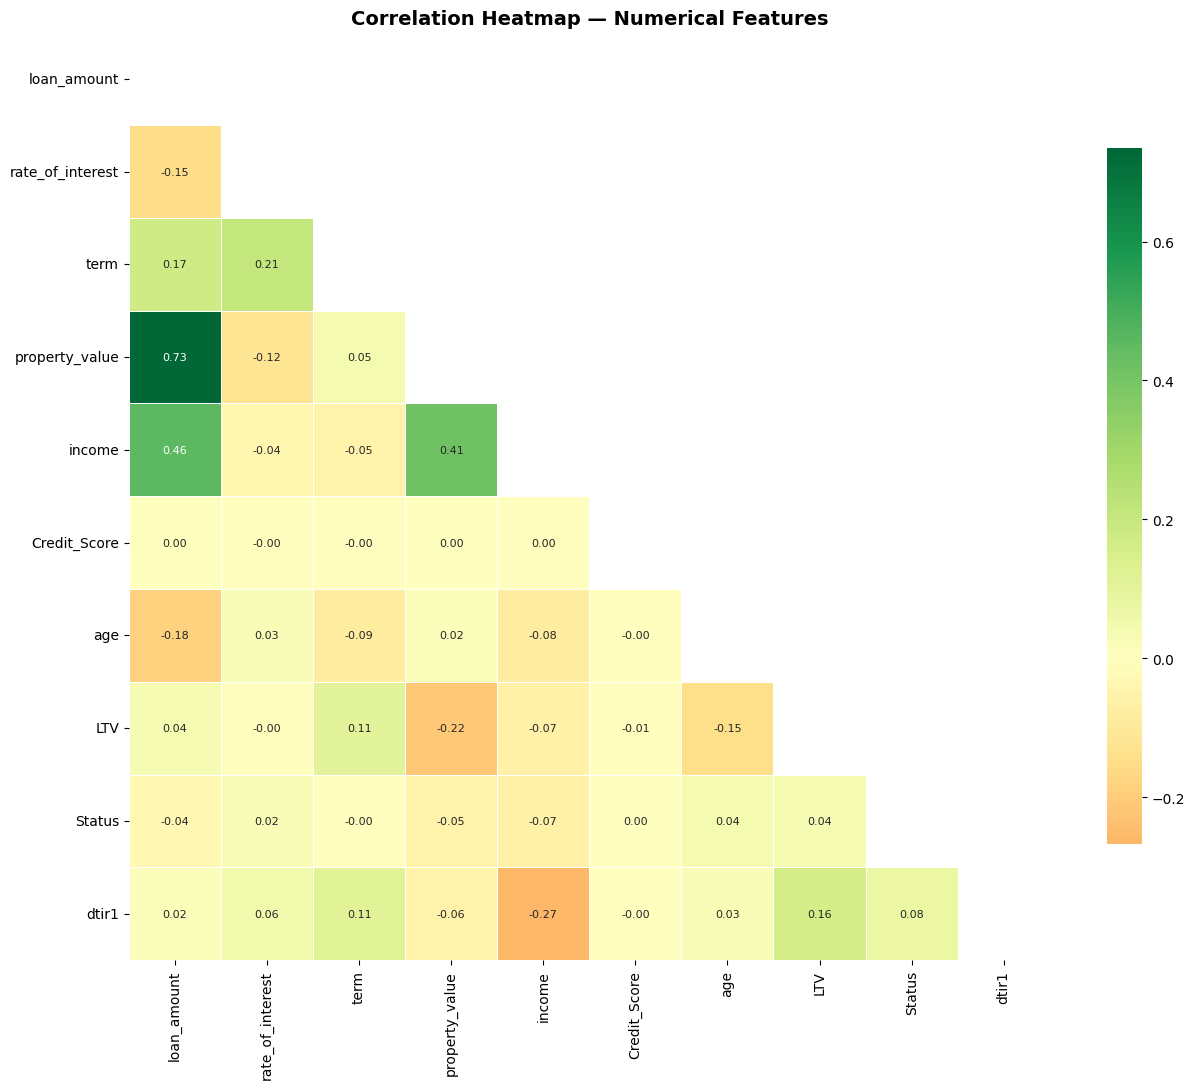

In [134]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, ax=ax,
    linewidths=0.4, cbar_kws={'shrink': 0.75},
    annot_kws={'size': 8}
)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
##  5. Feature Engineering <a id='5'></a>

### 5.1 Categorical Encoding (Label Encoding + One-Hot Encoding)
Automatically encode categorical columns: `LabelEncoder` for two-category (binary) columns,
one-hot encoding for columns with more than two categories.

In [135]:
'''
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in binary_cat:
    df[col] = le.fit_transform(df[col].astype(str))
'''
print(f"Label-encoded (binary) columns ({len(binary_cat)}): {binary_cat}")
print(f"\nOne-hot encoded (nominal) columns ({len(nominal_cat)}): {nominal_cat}")
print(f"\nShape after encoding: {df.shape}")

Label-encoded (binary) columns (9): ['Credit_Worthiness', 'open_credit', 'business_or_commercial', 'interest_only', 'lump_sum_payment', 'construction_type', 'Secured_by', 'co-applicant_credit_type', 'Security_Type']

One-hot encoded (nominal) columns (12): ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Neg_ammortization', 'occupancy_type', 'total_units', 'credit_type', 'age', 'submission_of_application', 'Region']

Shape after encoding: (148670, 30)


### 5.2 Domain-Specific Engineered Features

In [136]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        eps = 1e-6
        X['Loan_to_Income'] = X['loan_amount'] / (X['income'] + 1)
        X['Loan_to_Property'] = X['loan_amount'] / (X['property_value'] + 1)
        X['Debt_to_Income'] = X['dtir1'] / (X['income'] + 1)
        X['Score_LTV_ratio']   = X['Credit_Score'] / X['LTV'].clip(lower=eps)
        X['Interest_x_LTV']    = X['rate_of_interest'] * X['LTV'] / 100


        log_cols = [
            "loan_amount",
            "property_value",
            "income" ,
            "rate_of_interest"
        ]

        for col in log_cols:
            X[col] = np.log1p(X[col].clip(lower=0))


        return X

---
## 6. Handling Imbalanced Data <a id='6'></a>

The dataset has ~75.4% non-defaults vs ~24.6% defaults. We address this imbalance using:

| Strategy | Description | Applied To |
|----------|-------------|------------|
| **`class_weight=class_weights'`** | Assigns higher weight to minority-class misclassifications during training | Models that support it (LR, SVC, RF, DT) |
| **Evaluation metrics** | ROC-AUC and F1-Macro instead of raw accuracy | All evaluation |

In [137]:
print("Class distribution before any handling:")
vc = df['Status'].value_counts()
print(vc)
print(f"\nImbalance ratio: {vc[0]/vc[1]:.2f}:1")

Class distribution before any handling:
Status
0    112031
1     36639
Name: count, dtype: int64

Imbalance ratio: 3.06:1


---
##  7. Model Selection & Evaluation <a id='7'></a>

### 7.1 Train/Test Split

In [138]:
X = df.drop(columns='Status')
y = df['Status']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set : {x_train.shape[0]:,} samples")
print(f"  Class dist : {y_train.value_counts().to_dict()}")
print(f"\nTest set     : {x_test.shape[0]:,} samples")
print(f"  Class dist : {y_test.value_counts().to_dict()}")

Training set : 118,936 samples
  Class dist : {0: 89625, 1: 29311}

Test set     : 29,734 samples
  Class dist : {0: 22406, 1: 7328}


### 7.2 Preprocessing Pipeline

In [151]:
fe = FeatureEngineer()
x_train_fe = fe.transform(x_train)
x_test_fe = fe.transform(x_test)

num_train_cols = x_train_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()

cat_train_cols = x_train_fe.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print(f"Numeric features: {len(num_train_cols)}")
print(f"Categorical features: {len(cat_train_cols)}")

num_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

nom_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
cat_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_train_cols),
    ('nom', nom_transformer, nominal_cat) , 
    ('cat', cat_transformer, binary_cat)
])

Numeric features: 14
Categorical features: 20


### 7.3 Preprocess Training Data

Class imbalance is instead handled via `class_weight=class_weights` inside the models themselves.


In [140]:

X_train_proc = preprocessor.fit_transform(x_train_fe)
X_test_proc  = preprocessor.transform(x_test_fe)

print(f"After preprocessing — Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")

X_train_final, y_train_final = X_train_proc, y_train

print(f"\nClass distribution (train, unchanged): {pd.Series(y_train_final).value_counts().to_dict()}")


After preprocessing — Train: (118936, 35), Test: (29734, 35)

Class distribution (train, unchanged): {0: 89625, 1: 29311}


### 7.5 Train & Evaluate All Models

In [152]:
from imblearn.pipeline import Pipeline
from sklearn.base import clone
class_weights = {
    0: 0.66,
    1: 2.03
}
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight=class_weights
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=15,
        random_state=RANDOM_STATE,
        class_weight=class_weights
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        class_weight=class_weights,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=150,
        max_depth=10,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=150,
        max_depth=8,
        learning_rate=0.1,
        class_weight=class_weights,
        random_state=RANDOM_STATE,
        verbose=-1
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = []

print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

for name, model in models.items():

    pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("sampler", RandomUnderSampler(random_state=42)),
    ("classifier", model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1

    )
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score( y_test, y_pred, average="weighted",zero_division=0 )

    recall = recall_score( y_test, y_pred, average="weighted",zero_division=0 )

    f1 = f1_score( y_test, y_pred, average="weighted", zero_division=0 )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std()
    })

    print(f"\n{name}")
    print("-" * 60)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"CV Score : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


MODEL COMPARISON

Logistic Regression
------------------------------------------------------------
Accuracy : 0.5388
Precision: 0.7894
Recall   : 0.5388
F1 Score : 0.5559
CV Score : 0.5337 ± 0.0053

Decision Tree
------------------------------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
CV Score : 0.9998 ± 0.0001

Random Forest
------------------------------------------------------------
Accuracy : 0.9996
Precision: 0.9996
Recall   : 0.9996
F1 Score : 0.9996
CV Score : 0.9996 ± 0.0001

Gradient Boosting
------------------------------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
CV Score : 0.9999 ± 0.0001

Hist Gradient Boosting
------------------------------------------------------------
Accuracy : 0.9990
Precision: 0.9990
Recall   : 0.9990
F1 Score : 0.9990
CV Score : 0.9995 ± 0.0001

AdaBoost
------------------------------------------------------------
Accuracy : 1.0000


c:\Users\ahmed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [142]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=15,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=18,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=150,
        max_depth=10,
        learning_rate=0.1,
        random_state=RANDOM_STATE
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        verbosity=0
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=150,
        max_depth=8,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=-1
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)
smote_results = []

print("=" * 80)
print("MODEL COMPARISON USING SMOTE")
print("=" * 80)

for name, model in models.items():

    pipeline = Pipeline([
        ("feature_engineering", FeatureEngineer()),
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", model)
    ])

    cv_scores = cross_val_score(
        pipeline,
        x_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    smote_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "CV Mean": cv_scores.mean(),
        "CV Std": cv_scores.std()
    })
    print(f"\n{name}")
    print("-" * 60)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"CV Score : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

MODEL COMPARISON USING SMOTE

Logistic Regression
------------------------------------------------------------
Accuracy : 0.6943
Precision: 0.7549
Recall   : 0.6943
F1 Score : 0.7123
CV Score : 0.6941 ± 0.0018

Decision Tree
------------------------------------------------------------
Accuracy : 0.9997
Precision: 0.9997
Recall   : 0.9997
F1 Score : 0.9997
CV Score : 0.9994 ± 0.0003

Random Forest
------------------------------------------------------------
Accuracy : 0.9997
Precision: 0.9997
Recall   : 0.9997
F1 Score : 0.9997
CV Score : 0.9996 ± 0.0002

Gradient Boosting
------------------------------------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
CV Score : 0.9999 ± 0.0001

Hist Gradient Boosting
------------------------------------------------------------
Accuracy : 0.9990
Precision: 0.9990
Recall   : 0.9990
F1 Score : 0.9990
CV Score : 0.9992 ± 0.0003

AdaBoost
------------------------------------------------------------
Accura

c:\Users\ahmed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


---
##  8. Results & Insights <a id='8'></a>

### 8.1 Comparison Table

In [153]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(results_df)



FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Decision Tree,0.999966,0.999966,0.999966,0.999966,0.999849,0.000078
1,LightGBM,0.999966,0.999966,0.999966,0.999966,0.999874,0.000113
2,Gradient Boosting,0.999966,0.999966,0.999966,0.999966,0.999891,0.000112
3,AdaBoost,0.999966,0.999966,0.999966,0.999966,0.999849,0.000078
4,Random Forest,0.999596,0.999597,0.999596,0.999596,0.999638,0.000112
5,XGBoost,0.999126,0.999127,0.999126,0.999126,0.999100,0.000273
6,Hist Gradient Boosting,0.999025,0.999028,0.999025,0.999025,0.999453,0.000075
7,KNN,0.856326,0.866552,0.856326,0.859836,0.853863,0.003488
8,Logistic Regression,0.538777,0.789432,0.538777,0.555938,0.533674,0.005347


In [144]:
smote_results_df = (
    pd.DataFrame(smote_results)
      .sort_values(by="Accuracy", ascending=False)
      .reset_index(drop=True)
)

print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON (SMOTE)")
print("=" * 80)

display(smote_results_df)



FINAL MODEL COMPARISON (SMOTE)


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Gradient Boosting,1.000000,1.000000,1.000000,1.000000,0.999882,0.000126
1,LightGBM,0.999899,0.999899,0.999899,0.999899,0.999823,0.000129
2,Decision Tree,0.999697,0.999697,0.999697,0.999697,0.999369,0.000256
3,Random Forest,0.999664,0.999664,0.999664,0.999664,0.999647,0.000233
4,AdaBoost,0.999596,0.999597,0.999596,0.999596,0.999269,0.000359
5,XGBoost,0.999395,0.999395,0.999395,0.999395,0.999361,0.000175
6,Hist Gradient Boosting,0.998991,0.998993,0.998991,0.998991,0.999226,0.000298
7,KNN,0.831943,0.856687,0.831943,0.838898,0.830220,0.004060
8,Logistic Regression,0.694256,0.754923,0.694256,0.712262,0.694088,0.001776


In [145]:
# Class distribution before SMOTE
print("Before SMOTE:")
print(pd.Series(y_train).value_counts())
print()

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_proc, y_train)

# Class distribution after SMOTE
print("After SMOTE:")
print(pd.Series(y_smote).value_counts())

Before SMOTE:
Status
0    89625
1    29311
Name: count, dtype: int64

After SMOTE:
Status
0    89625
1    89625
Name: count, dtype: int64


> This means over 60,000 synthetic samples are created. While this balances the classes, it also introduces a large amount of artificial data. 
>For tree-based models (Random Forest, XGBoost, LightGBM), this often provides little benefit and can sometimes:

- increase training time,
- introduce synthetic noise,
- reduce generalization on real-world data.

### 8.2 Performance Comparison Charts

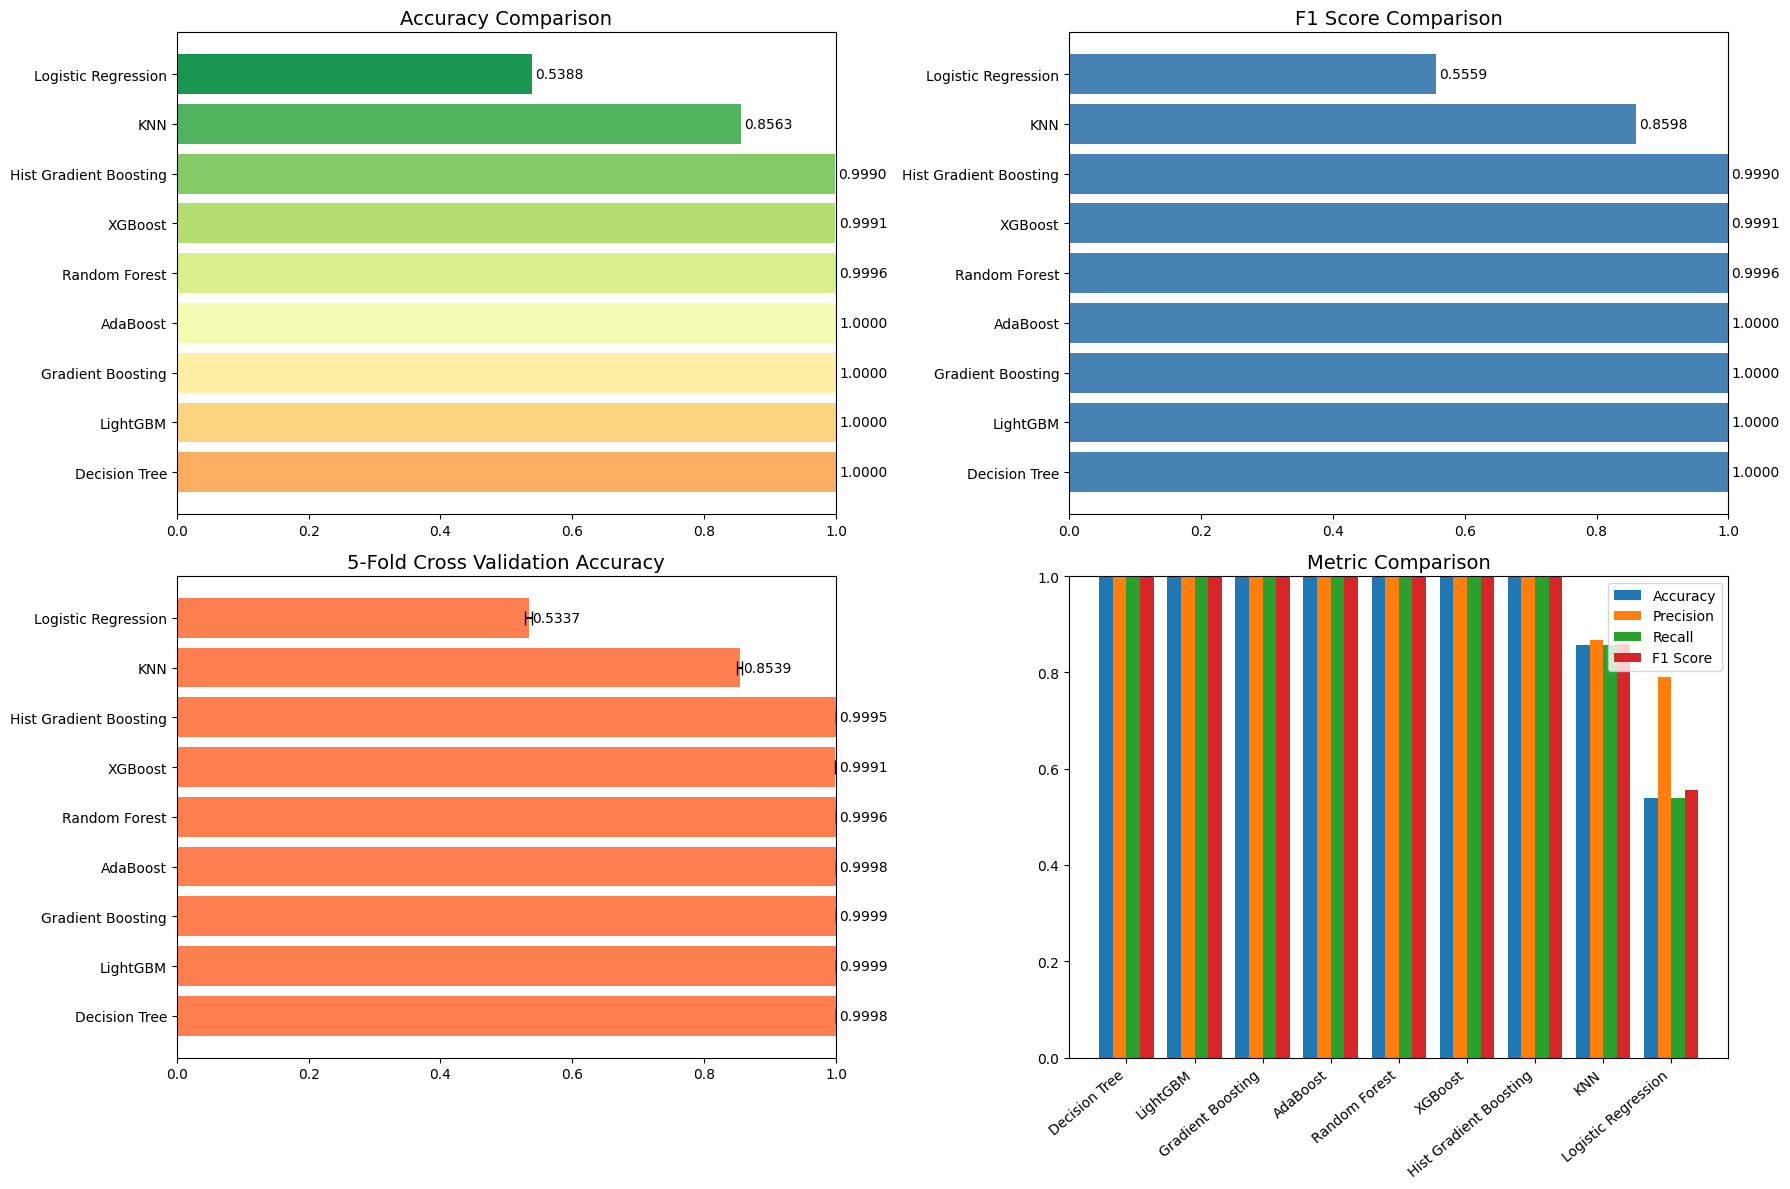

In [154]:
results_df = results_df.sort_values( by="Accuracy", ascending=False ).reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))


colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))

bars = axes[0,0].barh( results_df["Model"], results_df["Accuracy"], color=colors )

axes[0,0].set_title("Accuracy Comparison", fontsize=14)
axes[0,0].set_xlim(0, 1)

for bar, value in zip(bars, results_df["Accuracy"]):
    axes[0,0].text( value + 0.005, bar.get_y() + bar.get_height()/2, f"{value:.4f}",va="center")


bars = axes[0,1].barh( results_df["Model"], results_df["F1-Score"],color="steelblue")

axes[0,1].set_title("F1 Score Comparison", fontsize=14)
axes[0,1].set_xlim(0,1)

for bar, value in zip(bars, results_df["F1-Score"]):
    axes[0,1].text( value + 0.005, bar.get_y() + bar.get_height()/2,f"{value:.4f}",va="center")


bars = axes[1,0].barh(
    results_df["Model"],
    results_df["CV Mean"],
    color="coral",
    xerr=results_df["CV Std"],
    capsize=5
)

axes[1,0].set_title("5-Fold Cross Validation Accuracy", fontsize=14)
axes[1,0].set_xlim(0,1)

for bar, value in zip(bars, results_df["CV Mean"]):
    axes[1,0].text(value + 0.005,bar.get_y() + bar.get_height()/2,f"{value:.4f}",va="center")


x = np.arange(len(results_df))
width = 0.2

axes[1,1].bar(x - 1.5*width,results_df["Accuracy"],width,label="Accuracy")

axes[1,1].bar(x - 0.5*width,results_df["Precision"],width,label="Precision")

axes[1,1].bar(x + 0.5*width,results_df["Recall"],width,label="Recall")

axes[1,1].bar(x + 1.5*width,results_df["F1-Score"],width,label="F1 Score")

axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(results_df["Model"], rotation=40,ha="right")

axes[1,1].set_ylim(0,1)
axes[1,1].set_title("Metric Comparison", fontsize=14)
axes[1,1].legend()

plt.tight_layout()
plt.show()

---
##  9. Best Model Deep Dive <a id='9'></a>

In [155]:
best = results_df.iloc[0]

print(f" Best Model: {best['Model']}")
print(f"Accuracy : {best['Accuracy']:.4f}")
print(f"F1-Score : {best['F1-Score']:.4f}")


 Best Model: Decision Tree
Accuracy : 1.0000
F1-Score : 1.0000


# 10. Hyperparameter Tuning (RandomizedSearchCV) <a id='10-1'></a>

Tune the best-performing model using `RandomizedSearchCV` with stratified cross-validation.  
This searches a random subset of the hyperparameter space — much faster than `GridSearchCV` and almost as effective.

In [156]:
full_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("sampler", RandomUnderSampler(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=class_weights
    ))
])

param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", None],
    "model__bootstrap": [True, False],
    "model__criterion": ["gini", "entropy", "log_loss"]
}

random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=2
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True, False], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

In [157]:
best_model = random_search.best_estimator_
best_params = random_search.best_params_
print("Best Parameters:", best_params)
print("Best CV F1 Score:", random_search.best_score_)

Best Parameters: {'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__criterion': 'log_loss', 'model__bootstrap': False}
Best CV F1 Score: 0.9996931295025326


In [158]:
from sklearn.model_selection import GridSearchCV

best_params = random_search.best_params_

print("Random Search Best Parameters:")
print(best_params)

grid_param = {

    "model__n_estimators": sorted(list(set([
        max(50, best_params["model__n_estimators"] - 50),
        best_params["model__n_estimators"],
        best_params["model__n_estimators"] + 50
    ]))),

    "model__max_depth": sorted(list(set([
        max(2, best_params["model__max_depth"] - 2),
        best_params["model__max_depth"],
        best_params["model__max_depth"] + 2
    ]))) if best_params["model__max_depth"] is not None else [None],

    "model__min_samples_split": sorted(list(set([
        max(2, best_params["model__min_samples_split"] - 2),
        best_params["model__min_samples_split"],
        best_params["model__min_samples_split"] + 2
    ]))),

    "model__min_samples_leaf": sorted(list(set([
        max(1, best_params["model__min_samples_leaf"] - 1),
        best_params["model__min_samples_leaf"],
        best_params["model__min_samples_leaf"] + 1
    ]))),

    "model__max_features": [best_params["model__max_features"]],

    "model__bootstrap": [best_params["model__bootstrap"]]
}

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=grid_param,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

Random Search Best Parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__criterion': 'log_loss', 'model__bootstrap': False}
Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [False], 'model__max_depth': [18, 20, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [1, 2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [159]:
print("\n========== GRID SEARCH ==========")
print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nBest CV F1: {grid_search.best_score_:.4f}")


========== GRID SEARCH ==========
Best Parameters:
{'model__bootstrap': False, 'model__max_depth': 22, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 450}

Best CV F1: 0.9997


### 11. Stratified Cross-Validation <a id='10-4'></a>

A proper **5-fold stratified cross-validation** gives a more reliable estimate of generalisation performance than a single train/test split.  

In [160]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model = grid_search.best_estimator_

cv_results = cross_validate(
    best_model,
    x_train,
    y_train,
    cv=cv_strategy,
    scoring={
        'f1'       : 'f1',
        'roc_auc'  : 'roc_auc',
        'precision': 'precision',
        'recall'   : 'recall'
    },
    return_train_score=True,
    n_jobs=-1
)

cv_df = pd.DataFrame({
    'Fold'          : range(1, 6),
    'Train F1'      : cv_results['train_f1'],
    'Val F1'        : cv_results['test_f1'],
    'Train ROC-AUC' : cv_results['train_roc_auc'],
    'Val ROC-AUC'   : cv_results['test_roc_auc'],
    'Val Precision' : cv_results['test_precision'],
    'Val Recall'    : cv_results['test_recall'],
})

print("\n Cross-Validation Results Per Fold:")
print(cv_df.to_string(index=False))

print("\n Summary (Mean ± Std):")
print(f"  F1        → {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"  ROC-AUC   → {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"  Precision → {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  Recall    → {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")

print("\n Overfitting Check (Train - Val Gap):")
print(f"  F1 Gap      : {(cv_results['train_f1'].mean() - cv_results['test_f1'].mean()):.4f}")
print(f"  ROC-AUC Gap : {(cv_results['train_roc_auc'].mean() - cv_results['test_roc_auc'].mean()):.4f}")

y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:, 1]

print("\n Final Test Set Evaluation:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))


 Cross-Validation Results Per Fold:
 Fold  Train F1   Val F1  Train ROC-AUC  Val ROC-AUC  Val Precision  Val Recall
    1  0.999957 0.999829            1.0     1.000000       0.999659         1.0
    2  0.999979 0.999915            1.0     1.000000       0.999829         1.0
    3  0.999467 0.999318            1.0     0.999996       0.998637         1.0
    4  0.999510 0.999488            1.0     1.000000       0.998978         1.0
    5  0.999893 1.000000            1.0     1.000000       1.000000         1.0

 Summary (Mean ± Std):
  F1        → 0.9997 ± 0.0003
  ROC-AUC   → 1.0000 ± 0.0000
  Precision → 0.9994 ± 0.0005
  Recall    → 1.0000 ± 0.0000

 Overfitting Check (Train - Val Gap):
  F1 Gap      : 0.0001
  ROC-AUC Gap : 0.0000

 Final Test Set Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macr

### 12. Feature importance <a id='10-4'></a>

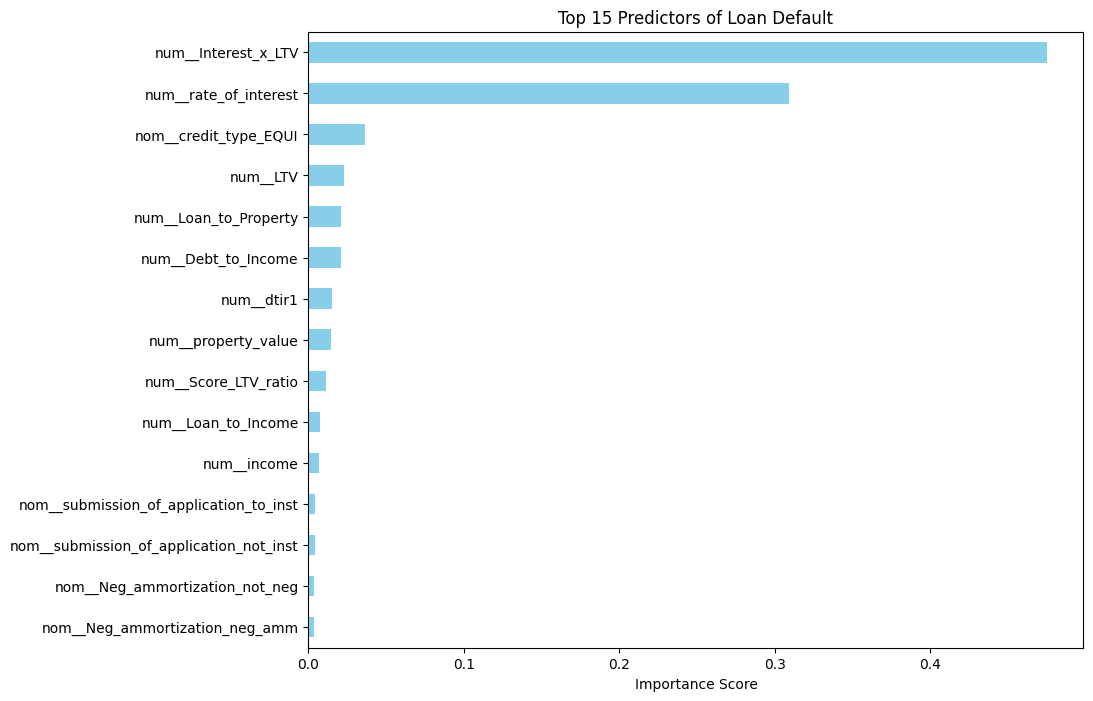

In [161]:
final_model = grid_search.best_estimator_

importances = final_model.named_steps['model'].feature_importances_
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Predictors of Loan Default')
plt.xlabel('Importance Score')
plt.show()

# 13.Classification Threshold Optimization and Confusion Matrix <a id='10-2'></a>

In [162]:

model_name = "Random Forest classfier"
best_rf = grid_search.best_estimator_

y_pred  = best_rf.predict(x_test)
y_proba = best_rf.predict_proba(x_test)


n_classes = len(np.unique(y_test))
print(f"\nNumber of classes: {n_classes}")
print(f"Classes: {np.unique(y_test)}")
acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')

print("\n" + "=" * 60)
print(f" EVALUATION - {model_name}")
print("=" * 60)
print(f"  Accuracy:    {acc:.6f}")
print(f"  F1-Score:    {f1:.6f}")
print(f"  Precision:   {prec:.6f}")
print(f"  Recall:      {rec:.6f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Number of classes: 2
Classes: [0 1]

 EVALUATION - Random Forest classfier
  Accuracy:    0.999899
  F1-Score:    0.999899
  Precision:   0.999899
  Recall:      0.999899

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734


Confusion Matrix:
[[22404     2]
 [    1  7327]]


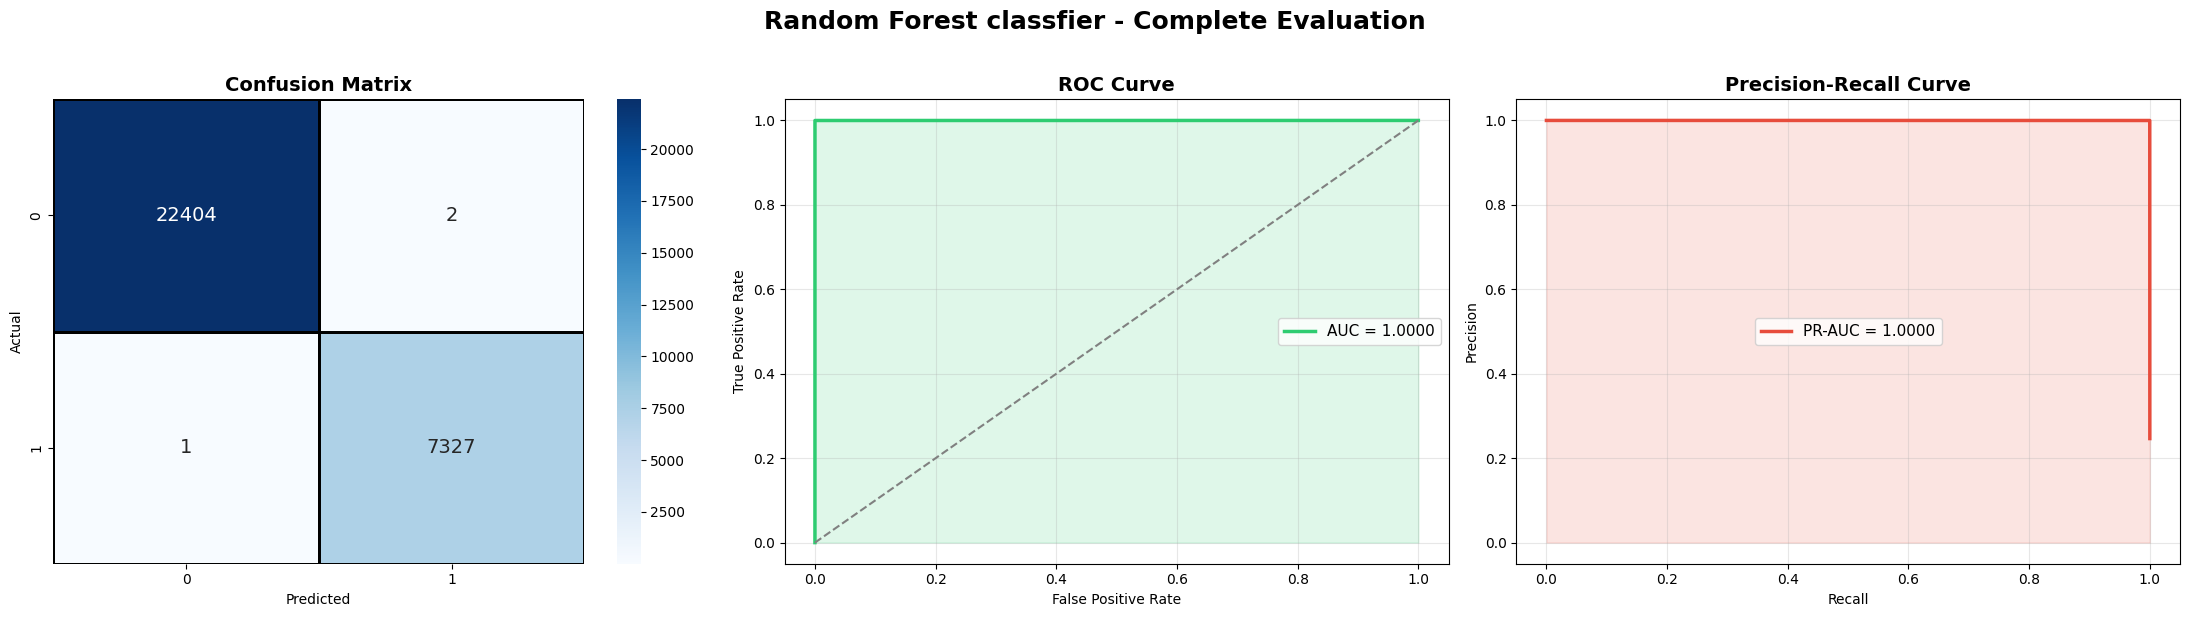

In [163]:
y_proba_pos = y_proba[:, 1]

roc_auc = roc_auc_score(y_test, y_proba_pos)
fpr, tpr, _ = roc_curve(y_test, y_proba_pos)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_pos)
pr_auc = average_precision_score(y_test, y_proba_pos)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
          xticklabels=np.unique(y_test),
          yticklabels=np.unique(y_test),
          linewidths=1, linecolor='black',
          annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].plot(fpr, tpr, color='#2ecc71', linewidth=2.5,
            label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#2ecc71')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(recall_curve, precision_curve, color='#e74c3c', linewidth=2.5,
            label=f"PR-AUC = {pr_auc:.4f}")
axes[2].fill_between(recall_curve, precision_curve, alpha=0.15, color='#e74c3c')
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve", fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'{model_name} - Complete Evaluation',
              fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 14. Production Pipeline <a id='10-5'></a>

In [164]:
import joblib
from sklearn.metrics import roc_auc_score

production_pipeline = random_search.best_estimator_

save_path = "loan_default_pipeline.pkl"
joblib.dump(production_pipeline, save_path)

loaded_pipeline = joblib.load(save_path)

y_loaded_prob = loaded_pipeline.predict_proba(x_test)[:, 1]

print(f"Loaded Pipeline ROC-AUC: {roc_auc_score(y_test, y_loaded_prob):.4f}")
print(f"Model saved successfully at:\n{save_path}")

Loaded Pipeline ROC-AUC: 1.0000
Model saved successfully at:
loan_default_pipeline.pkl
